# Mapping Micro-Refuge Potential Around Bryant Park

**Reality-based question:** If I only have about fifteen minutes around Bryant Park and want a relatively screened place for a short pause, how should I choose where to go?

This version separates two layers:
1. a **visual-condition field** measured at 10 m intervals along streets; and
2. **real NYC DOT pause infrastructure** (benches + leaning bars) within an approximate 15-minute preparation radius.

The street samples are measurement locations, not destinations. The DOT seating assets are the actual pause candidates that will later become the selectable destinations in the web application.

## 01 — Research Logic

A place that allows stopping does not automatically provide retreat. In a dense public environment, a person may still feel continuously exposed to surrounding movement and urban edges.

The project therefore defines a **micro-refuge** as a public, short-duration pause location that offers some potential visual buffering. It does **not** claim to measure privacy, safety, comfort, or whether a person can literally be seen.

The computational chain is:

**15-minute pause need → public DOT seating → visual buffering as one measurable dimension → 10 m street samples → tree/building proximity → visual-condition field → attach conditions to real pause candidates → web decision tool**

## 02 — Project Workflow

![Project workflow](figures/final-project-workflow.png)

## 03 — Import libraries and define project settings

In [24]:
from pathlib import Path
import json
import warnings

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from shapely.geometry import Point
from shapely.ops import substring

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

TARGET_CRS = "EPSG:2263"
M_PER_FT = 0.3048006096
SAMPLE_INTERVAL_M = 10.0
SAMPLE_INTERVAL_FT = SAMPLE_INTERVAL_M / M_PER_FT

# Reality-based scope
BRYANT_CENTER_LON = -73.9832
BRYANT_CENTER_LAT = 40.7536
WALK_BUDGET_MIN = 15
ASSUMED_WALK_SPEED_M_PER_MIN = 80.0
ANALYSIS_RADIUS_M = WALK_BUDGET_MIN * ASSUMED_WALK_SPEED_M_PER_MIN  # 1,200 m prep radius
SOURCE_PADDING_M = 150.0  # prevents edge bias in nearest-tree/building measurements

# -----------------------------------------------------------------------------
# VISUAL SYSTEM — synchronized with the web prototype
# White map, black/gray urban geometry, green-led condition palette.
# -----------------------------------------------------------------------------
WHITE = "#FFFFFF"
BLACK = "#111111"
INK = "#252525"
CHARCOAL = "#3A3A3A"
MID_GRAY = "#AEB2AD"
LIGHT_GRAY = "#D9DCD7"
PALE_GRAY = "#F1F2EF"

DEEP_GREEN = "#1F5A43"
MID_GREEN = "#4C8A5B"
LIGHT_GREEN = "#86B978"
YELLOW = "#E2C84A"
LIME = "#C8E63C"
BLUE = "#2F6FB0"

TREE_DISTANCE_CMAP = LinearSegmentedColormap.from_list(
    "tree_distance_green", [DEEP_GREEN, MID_GREEN, LIGHT_GREEN, YELLOW, LIME]
)
BUILDING_DISTANCE_CMAP = LinearSegmentedColormap.from_list(
    "building_distance_green", [DEEP_GREEN, MID_GREEN, LIGHT_GREEN, YELLOW, LIME]
)

VISUAL_COLORS = {
    "Exposed Edge": BLUE,
    "Screened Edge": DEEP_GREEN,
    "Vegetated Buffer": LIGHT_GREEN,
    "Open Field": YELLOW,
}
CATEGORY_ORDER = ["Exposed Edge", "Screened Edge", "Vegetated Buffer", "Open Field"]

plt.rcParams.update({
    "figure.facecolor": WHITE,
    "axes.facecolor": WHITE,
    "savefig.facecolor": WHITE,
    "text.color": INK,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "axes.edgecolor": CHARCOAL,
    "font.size": 11,
})

print("GeoPandas:", gpd.__version__)
print(f"Sampling interval: {SAMPLE_INTERVAL_M:.0f} m")
print(f"Preparation radius: {ANALYSIS_RADIUS_M:.0f} m ≈ {WALK_BUDGET_MIN} minutes at {ASSUMED_WALK_SPEED_M_PER_MIN:.0f} m/min")


GeoPandas: 1.1.3
Sampling interval: 10 m
Preparation radius: 1200 m ≈ 15 minutes at 80 m/min


## 04 — Define the approximate 15-minute Bryant Park study area

The research question is time-based, so the study extent is also time-based. For data preparation, 15 minutes is translated into a **1,200 m radial catchment** using an 80 m/min walking assumption.

This circle is only a **candidate-pool boundary**. It is not treated as an actual walkshed. The later web application will use the pedestrian network to calculate real 5 / 10 / 15-minute reachability from the user's selected location.

Trees and buildings are downloaded with an additional 150 m padding so samples near the analysis boundary can still find nearby features outside the circle.

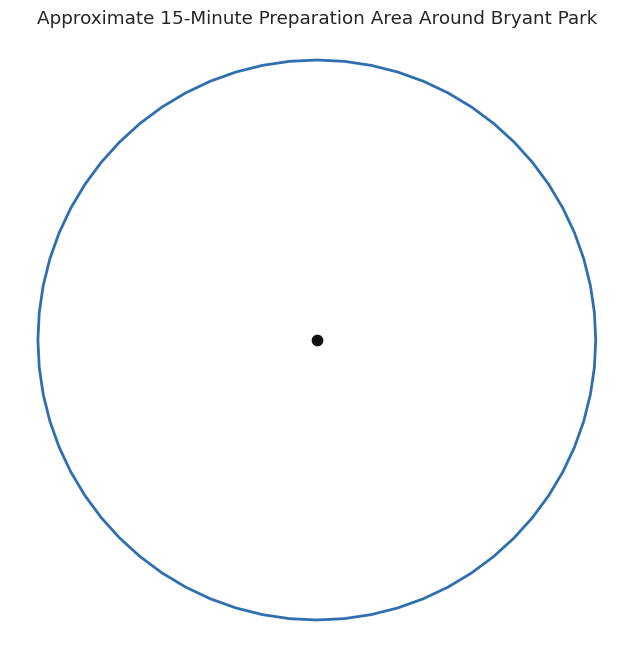

API fetch bbox: (np.float64(-73.99919), np.float64(40.74144), np.float64(-73.96721), np.float64(40.76576))


In [25]:
center_wgs = gpd.GeoDataFrame(
    {"name": ["Bryant Park reference point"]},
    geometry=[Point(BRYANT_CENTER_LON, BRYANT_CENTER_LAT)],
    crs="EPSG:4326"
)
center_projected = center_wgs.to_crs(TARGET_CRS)

study_area_projected = gpd.GeoDataFrame(
    {"name": ["Approximate 15-minute preparation area"]},
    geometry=center_projected.geometry.buffer(ANALYSIS_RADIUS_M / M_PER_FT),
    crs=TARGET_CRS
)
source_area_projected = gpd.GeoDataFrame(
    {"name": ["Source fetch area with padding"]},
    geometry=center_projected.geometry.buffer((ANALYSIS_RADIUS_M + SOURCE_PADDING_M) / M_PER_FT),
    crs=TARGET_CRS
)

study_area = study_area_projected.to_crs("EPSG:4326")
source_area = source_area_projected.to_crs("EPSG:4326")
WEST, SOUTH, EAST, NORTH = source_area.total_bounds

fig, ax = plt.subplots(figsize=(8, 8))
study_area.boundary.plot(ax=ax, color=BLUE, linewidth=2.0)
center_wgs.plot(ax=ax, color=BLACK, markersize=55, zorder=3)
ax.set_title("Approximate 15-Minute Preparation Area Around Bryant Park")
ax.set_axis_off()
plt.show()

print("API fetch bbox:", tuple(round(v, 5) for v in (WEST, SOUTH, EAST, NORTH)))


## 05 — Load the three environmental source datasets

The 15-minute version needs a larger environmental field than the earlier Bryant Park core study. Therefore it uses separate `*_15min.geojson` cache files.

On the **first run**, the notebook downloads the expanded NYC Open Data subsets. Later runs load those local files directly. The active data sources are:

- NYC Street Centerline
- 2015 Street Tree Census
- NYC Building Footprints

The DOT seating dataset is loaded later as the real pause-candidate layer.

In [26]:
DATASETS = {
    "streets": {"id": "inkn-q76z", "local": DATA_DIR / "streets_15min.geojson", "source": "NYC Street Centerline"},
    "trees": {"id": "uvpi-gqnh", "local": DATA_DIR / "trees_15min.geojson", "source": "2015 Street Tree Census"},
    "buildings": {"id": "5zhs-2jue", "local": DATA_DIR / "buildings_15min.geojson", "source": "NYC Building Footprints"},
}
BASE_RESOURCE = "https://data.cityofnewyork.us/resource"
SESSION = requests.Session()
SESSION.trust_env = False


def download_socrata_geojson(dataset_id, output_path, bbox, limit=50000):
    west, south, east, north = bbox
    errors = []
    for geom_field in ["the_geom", "geometry"]:
        where = f"within_box({geom_field}, {north}, {west}, {south}, {east})"
        try:
            response = SESSION.get(
                f"{BASE_RESOURCE}/{dataset_id}.geojson",
                params={"$limit": limit, "$where": where}, timeout=120
            )
            response.raise_for_status()
            payload = response.json()
            if payload.get("type") == "FeatureCollection":
                output_path.write_text(json.dumps(payload), encoding="utf-8")
                return gpd.read_file(output_path)
        except Exception as exc:
            errors.append(str(exc))
    raise RuntimeError("Automatic download failed: " + " | ".join(errors))


def download_tree_points(output_path, bbox, limit=50000):
    west, south, east, north = bbox
    response = SESSION.get(
        f"{BASE_RESOURCE}/uvpi-gqnh.json",
        params={
            "$limit": limit,
            "$where": (
                f"latitude >= {south} AND latitude <= {north} "
                f"AND longitude >= {west} AND longitude <= {east}"
            ),
        }, timeout=120
    )
    response.raise_for_status()
    records = response.json()
    valid = [r for r in records if r.get("longitude") and r.get("latitude")]
    trees = gpd.GeoDataFrame(
        valid,
        geometry=gpd.points_from_xy(
            [float(r["longitude"]) for r in valid],
            [float(r["latitude"]) for r in valid]
        ),
        crs="EPSG:4326"
    )
    trees.to_file(output_path, driver="GeoJSON")
    return trees


def load_or_download(name):
    info = DATASETS[name]
    if info["local"].exists():
        print(f"Loading local {name}: {info['local']}")
        return gpd.read_file(info["local"])
    if name == "trees":
        return download_tree_points(info["local"], (WEST, SOUTH, EAST, NORTH))
    return download_socrata_geojson(info["id"], info["local"], (WEST, SOUTH, EAST, NORTH))

streets_raw = load_or_download("streets")
trees_raw = load_or_download("trees")
buildings_raw = load_or_download("buildings")

print("Street features:", len(streets_raw))
print("Tree features:", len(trees_raw))
print("Building features:", len(buildings_raw))

Loading local streets: data/streets_15min.geojson
Loading local trees: data/trees_15min.geojson
Loading local buildings: data/buildings_15min.geojson
Street features: 1375
Tree features: 6397
Building features: 6082


## 06 — Prepare the street field and padded environmental layers

Prepared streets: 962
Prepared trees (padded source area): 5,126
Prepared buildings (padded source area): 5,111


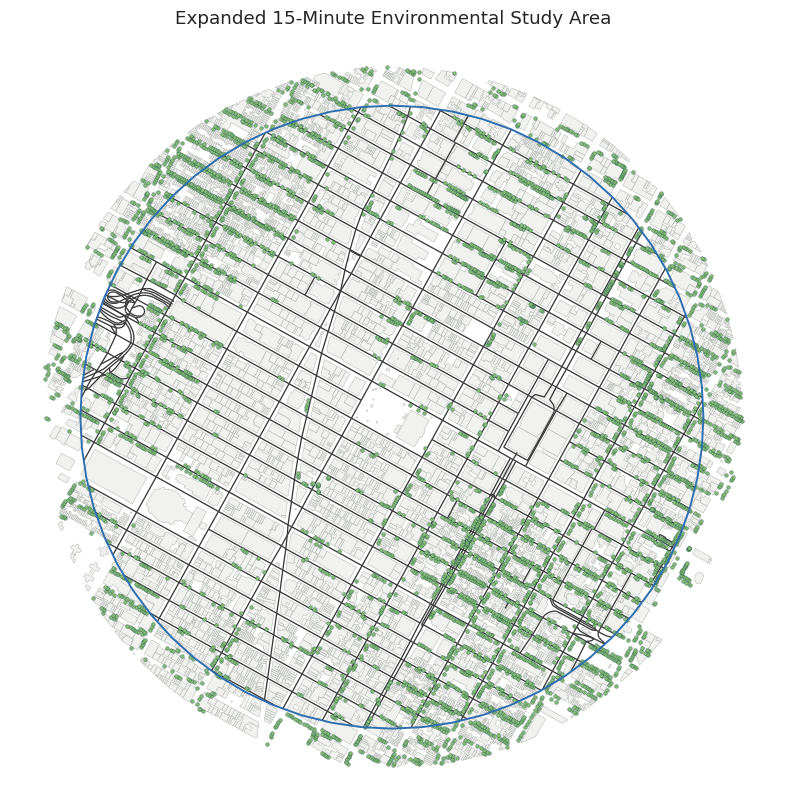

In [27]:
def clean_layer(layer):
    if layer.crs is None:
        raise ValueError("A source layer has no CRS.")
    layer = layer.to_crs(TARGET_CRS).copy()
    layer = layer[layer.geometry.notna() & ~layer.geometry.is_empty].copy()
    layer["geometry"] = layer.geometry.make_valid()
    return layer

streets_raw_p = clean_layer(streets_raw)
trees_raw_p = clean_layer(trees_raw)
buildings_raw_p = clean_layer(buildings_raw)

# Only streets inside the 15-minute prep area are sampled.
streets = gpd.clip(streets_raw_p, study_area_projected)
# Trees/buildings keep the padded area to reduce boundary bias.
trees = gpd.clip(trees_raw_p, source_area_projected)
buildings = gpd.clip(buildings_raw_p, source_area_projected)

streets = streets[streets.geometry.geom_type.isin(["LineString", "MultiLineString"])].copy()
trees = trees[trees.geometry.geom_type == "Point"].copy()
buildings = buildings[buildings.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

streets = streets.explode(index_parts=False).reset_index(drop=True)
streets["segment_id"] = [f"SEG_{i:05d}" for i in range(1, len(streets) + 1)]

print(f"Prepared streets: {len(streets):,}")
print(f"Prepared trees (padded source area): {len(trees):,}")
print(f"Prepared buildings (padded source area): {len(buildings):,}")

fig, ax = plt.subplots(figsize=(10, 10))
buildings.plot(ax=ax, facecolor=PALE_GRAY, edgecolor=MID_GRAY, linewidth=0.35, alpha=0.95, zorder=1)
streets.plot(ax=ax, color=CHARCOAL, linewidth=0.95, zorder=2)
trees.plot(ax=ax, color=LIGHT_GREEN, edgecolor=DEEP_GREEN, linewidth=0.25, markersize=7, zorder=3)
study_area_projected.boundary.plot(ax=ax, color=BLUE, linewidth=1.4, zorder=4)
ax.set_title("Expanded 15-Minute Environmental Study Area")
ax.set_axis_off()
plt.show()


## 07 — Replace one midpoint with 10 m street sampling

Each street segment is sampled at regular intervals. Samples are placed at the center of each 10 m interval (approximately 5 m, 15 m, 25 m, … from the segment start) to reduce the influence of intersection endpoints.

Very short segments receive one midpoint sample.

This change allows the model to capture **within-segment variation** rather than assigning one value to an entire street.

Street segments: 962
Sampling points: 8,894
Mean samples per segment: 9.2


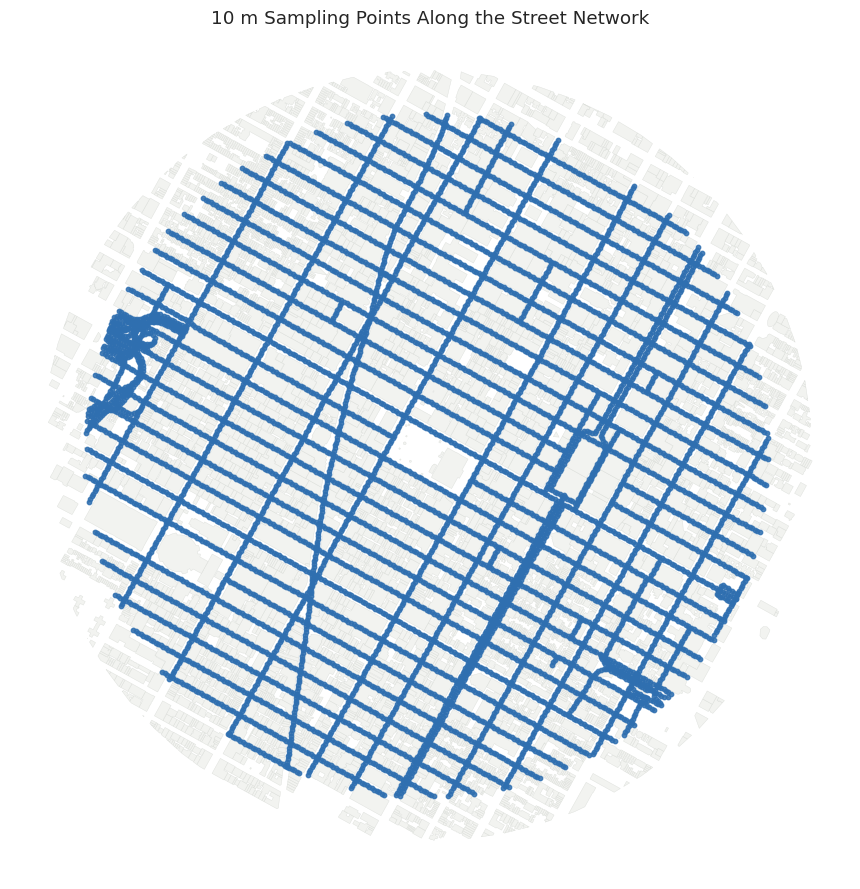

,segment_id,street_name,sample_index,sample_id,distance_along_m,geometry
0,SEG_00001,LEXINGTON AVE,1,SEG_00001_P001,5.0,POINT (989153.519 209923.148)
1,SEG_00001,LEXINGTON AVE,2,SEG_00001_P002,15.0,POINT (989169.319 209951.901)
2,SEG_00001,LEXINGTON AVE,3,SEG_00001_P003,25.0,POINT (989185.118 209980.655)
3,SEG_00001,LEXINGTON AVE,4,SEG_00001_P004,35.0,POINT (989200.918 210009.408)
4,SEG_00001,LEXINGTON AVE,5,SEG_00001_P005,45.0,POINT (989216.718 210038.161)


In [28]:
sample_records = []

for _, row in streets.iterrows():
    geom = row.geometry
    length_ft = geom.length

    if length_ft <= SAMPLE_INTERVAL_FT:
        distances_ft = [length_ft / 2]
    else:
        distances_ft = np.arange(SAMPLE_INTERVAL_FT / 2, length_ft, SAMPLE_INTERVAL_FT)
        if len(distances_ft) == 0:
            distances_ft = [length_ft / 2]

    for sample_index, distance_ft in enumerate(distances_ft, start=1):
        sample_records.append({
            "segment_id": row["segment_id"],
            "street_name": row.get("stname_label", ""),
            "sample_index": sample_index,
            "sample_id": f"{row['segment_id']}_P{sample_index:03d}",
            "distance_along_m": float(distance_ft) * M_PER_FT,
            "geometry": geom.interpolate(float(distance_ft)),
        })

sample_points = gpd.GeoDataFrame(sample_records, geometry="geometry", crs=streets.crs)

print(f"Street segments: {len(streets):,}")
print(f"Sampling points: {len(sample_points):,}")
print(f"Mean samples per segment: {len(sample_points) / len(streets):.1f}")

fig, ax = plt.subplots(figsize=(11, 11))
buildings.plot(ax=ax, facecolor=PALE_GRAY, edgecolor=LIGHT_GRAY, linewidth=0.3, alpha=0.9, zorder=1)
streets.plot(ax=ax, color=MID_GRAY, linewidth=0.9, zorder=2)
sample_points.plot(ax=ax, color=BLUE, markersize=10, alpha=0.85, zorder=3)
ax.set_title("10 m Sampling Points Along the Street Network")
ax.set_axis_off()
plt.show()

sample_points.head()


## 08 — Measure distance to the nearest tree at every sample point

Shorter tree distance is treated as stronger **potential vegetation screening**. It is a proximity proxy, not a direct measurement of canopy obstruction.

In [29]:
tree_join = gpd.sjoin_nearest(
    sample_points,
    trees[["geometry"]],
    how="left",
    distance_col="tree_distance_ft"
)

tree_distances = (
    tree_join.groupby("sample_id", as_index=False)["tree_distance_ft"].min()
)
tree_distances["tree_distance_m"] = tree_distances["tree_distance_ft"] * M_PER_FT

tree_distances["tree_distance_m"].describe()

count    8894.000000
mean       36.770448
std        37.016462
min         0.123379
25%         9.152127
50%        20.557770
75%        56.306560
max       203.139113
Name: tree_distance_m, dtype: float64

### Tree-distance field

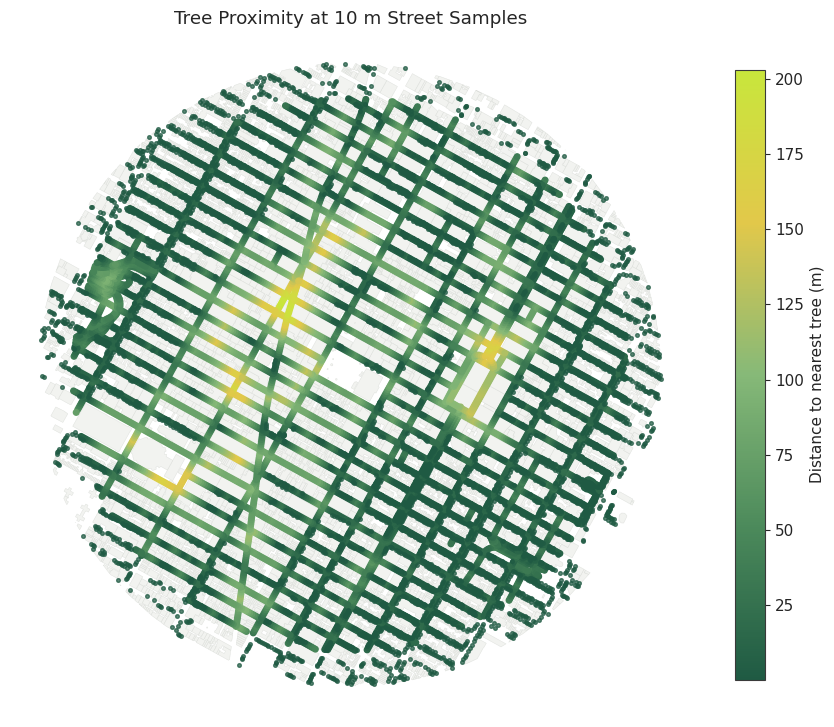

In [30]:
tree_samples = sample_points.merge(
    tree_distances[["sample_id", "tree_distance_m"]], on="sample_id", how="left"
)

fig, ax = plt.subplots(figsize=(11, 11))
buildings.plot(ax=ax, facecolor=PALE_GRAY, edgecolor=LIGHT_GRAY, linewidth=0.3, alpha=0.9, zorder=1)
streets.plot(ax=ax, color=MID_GRAY, linewidth=0.7, alpha=0.72, zorder=2)
tree_samples.plot(
    ax=ax, column="tree_distance_m", cmap=TREE_DISTANCE_CMAP,
    legend=True, markersize=16, zorder=3,
    legend_kwds={"label": "Distance to nearest tree (m)", "shrink": 0.72}
)
trees.plot(ax=ax, color=DEEP_GREEN, markersize=7, alpha=0.72, zorder=4)
ax.set_title("Tree Proximity at 10 m Street Samples")
ax.set_axis_off()
plt.show()


## 09 — Measure distance to the nearest building edge at every sample point

Building-edge distance describes the sample location’s relationship to the surrounding built edge. It does not mean that a nearby building is actively observing the street.

In [31]:
building_join = gpd.sjoin_nearest(
    sample_points,
    buildings[["geometry"]],
    how="left",
    distance_col="building_distance_ft"
)

building_distances = (
    building_join.groupby("sample_id", as_index=False)["building_distance_ft"].min()
)
building_distances["building_distance_m"] = building_distances["building_distance_ft"] * M_PER_FT

building_distances["building_distance_m"].describe()

count    8894.000000
mean       12.769000
std         7.532173
min         0.000000
25%         9.091282
50%         9.927373
75%        15.043718
max        87.078140
Name: building_distance_m, dtype: float64

### Building-distance field

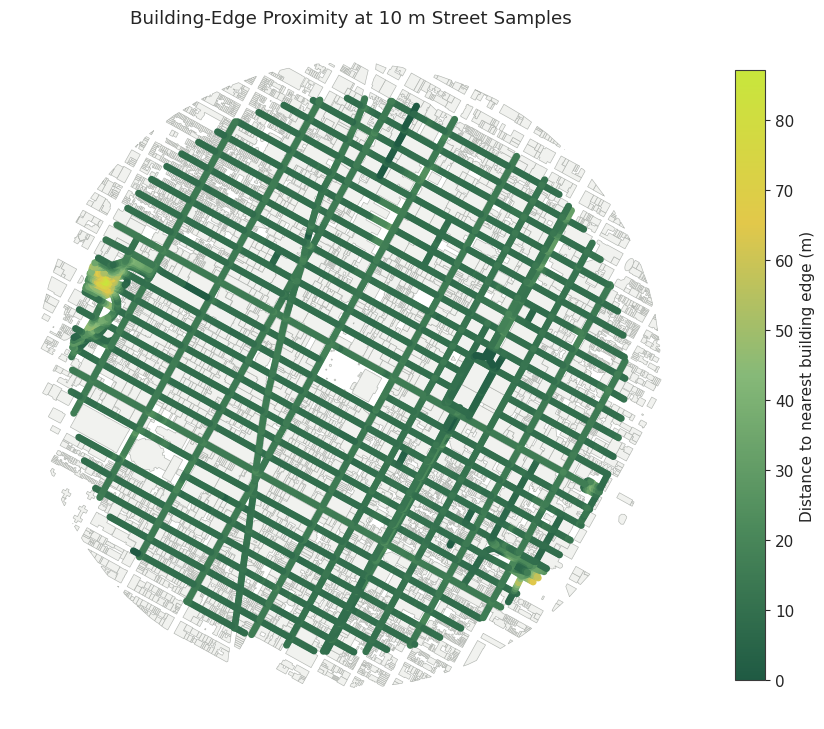

In [32]:
building_samples = sample_points.merge(
    building_distances[["sample_id", "building_distance_m"]], on="sample_id", how="left"
)

fig, ax = plt.subplots(figsize=(11, 11))
buildings.plot(ax=ax, facecolor=PALE_GRAY, edgecolor=MID_GRAY, linewidth=0.45, alpha=0.95, zorder=1)
streets.plot(ax=ax, color=LIGHT_GRAY, linewidth=0.7, alpha=0.8, zorder=2)
building_samples.plot(
    ax=ax, column="building_distance_m", cmap=BUILDING_DISTANCE_CMAP,
    legend=True, markersize=16, zorder=3,
    legend_kwds={"label": "Distance to nearest building edge (m)", "shrink": 0.72}
)
ax.set_title("Building-Edge Proximity at 10 m Street Samples")
ax.set_axis_off()
plt.show()


## 10 — Merge both measurements on the sample-point unit

In [33]:
sample_results = (
    sample_points
    .merge(tree_distances[["sample_id", "tree_distance_m"]], on="sample_id", how="left")
    .merge(building_distances[["sample_id", "building_distance_m"]], on="sample_id", how="left")
)

sample_results[[
    "sample_id", "segment_id", "street_name", "distance_along_m",
    "tree_distance_m", "building_distance_m", "geometry"
]].head()

,sample_id,segment_id,street_name,distance_along_m,tree_distance_m,building_distance_m,geometry
0,SEG_00001_P001,SEG_00001,LEXINGTON AVE,5.0,16.692101,11.708801,POINT (989153.519 209923.148)
1,SEG_00001_P002,SEG_00001,LEXINGTON AVE,15.0,8.985736,12.085701,POINT (989169.319 209951.901)
2,SEG_00001_P003,SEG_00001,LEXINGTON AVE,25.0,8.626068,11.089291,POINT (989185.118 209980.655)
3,SEG_00001_P004,SEG_00001,LEXINGTON AVE,35.0,9.486817,11.024851,POINT (989200.918 210009.408)
4,SEG_00001_P005,SEG_00001,LEXINGTON AVE,45.0,7.907213,10.563369,POINT (989216.718 210038.161)


## 11 — Convert both distances into relative Near / Far conditions

The study-area median is used as a transparent relative threshold. This is **not** a universal perceptual threshold; it only distinguishes lower and higher distances within this study area.

In [34]:
tree_threshold = sample_results["tree_distance_m"].median()
building_threshold = sample_results["building_distance_m"].median()

sample_results["tree_class"] = np.where(
    sample_results["tree_distance_m"] <= tree_threshold, "Tree Near", "Tree Far"
)
sample_results["building_class"] = np.where(
    sample_results["building_distance_m"] <= building_threshold, "Building Near", "Building Far"
)

print(f"Tree median threshold: {tree_threshold:.2f} m")
print(f"Building median threshold: {building_threshold:.2f} m")

Tree median threshold: 20.56 m
Building median threshold: 9.93 m


## 12 — Four visual spatial conditions

The project no longer treats visual exposure as one high-to-low score. Instead, the two relationships produce four different spatial states:

| Building relation | Tree relation | Visual condition | Interpretation |
|---|---|---|---|
| Near | Far | **Exposed Edge** | Strong built-edge relation with weak vegetation screening. |
| Near | Near | **Screened Edge** | Built edge and vegetation screening coexist. |
| Far | Near | **Vegetated Buffer** | Vegetation is close while built edges are relatively farther away. |
| Far | Far | **Open Field** | Both nearby vegetation and built edges are relatively distant. |

For the future micro-refuge application, **Screened Edge** and **Vegetated Buffer** represent stronger screening potential, but they are not automatically “better” or confirmed rest locations.

In [35]:
def classify_visual_condition(row):
    building_near = row["building_class"] == "Building Near"
    tree_near = row["tree_class"] == "Tree Near"

    if building_near and not tree_near:
        return "Exposed Edge"
    if building_near and tree_near:
        return "Screened Edge"
    if (not building_near) and tree_near:
        return "Vegetated Buffer"
    return "Open Field"

sample_results["visual_condition"] = sample_results.apply(classify_visual_condition, axis=1)
sample_results["visual_condition"] = pd.Categorical(
    sample_results["visual_condition"], categories=CATEGORY_ORDER, ordered=True
)

condition_summary = (
    sample_results["visual_condition"]
    .value_counts(sort=False)
    .rename_axis("visual_condition")
    .reset_index(name="sample_count")
)
condition_summary["percentage"] = (
    condition_summary["sample_count"] / condition_summary["sample_count"].sum() * 100
).round(1)

display(condition_summary)

,visual_condition,sample_count,percentage
0,Exposed Edge,2101,23.6
1,Screened Edge,2346,26.4
2,Vegetated Buffer,2101,23.6
3,Open Field,2346,26.4


## 13 — High-resolution visual-condition field

Unlike the original midpoint model, this map can show changes **within the same street segment**.

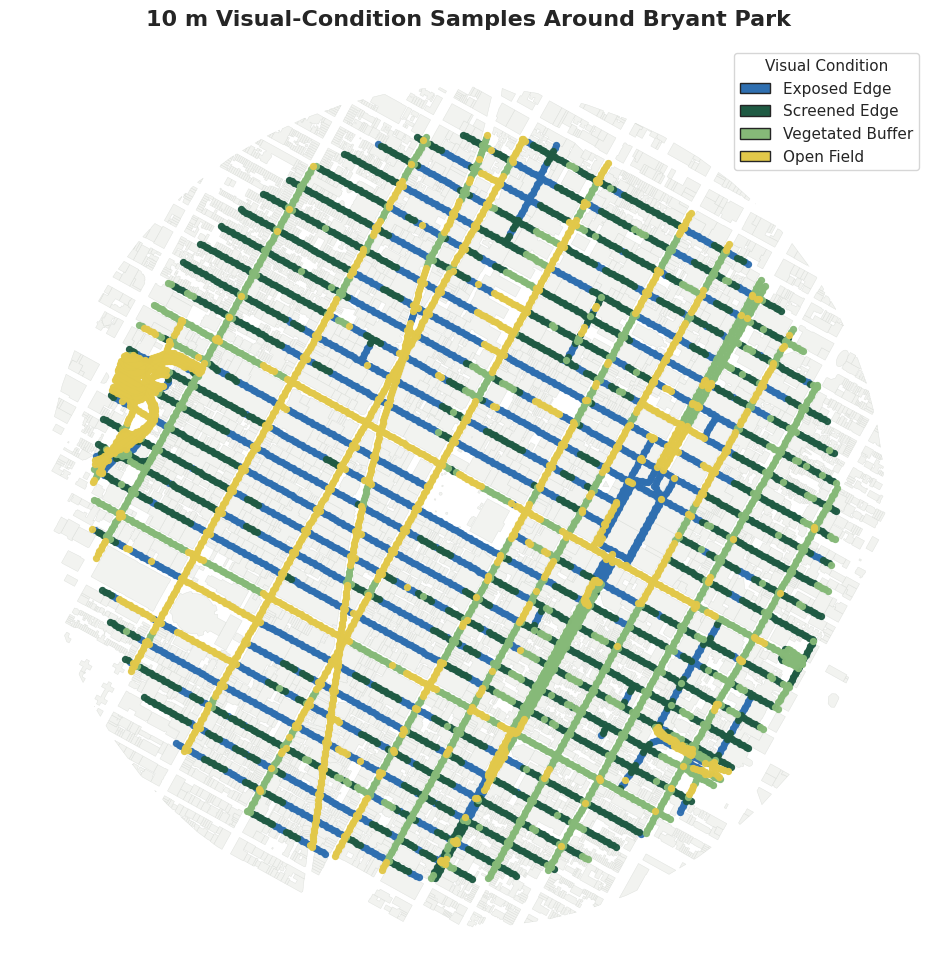

In [36]:
fig, ax = plt.subplots(figsize=(12, 12))
buildings.plot(ax=ax, facecolor=PALE_GRAY, edgecolor=LIGHT_GRAY, linewidth=0.3, alpha=0.9, zorder=1)
streets.plot(ax=ax, color=MID_GRAY, linewidth=0.8, alpha=0.75, zorder=2)

for condition in CATEGORY_ORDER:
    subset = sample_results[sample_results["visual_condition"] == condition]
    subset.plot(
        ax=ax, color=VISUAL_COLORS[condition], markersize=18,
        alpha=0.95, zorder=3
    )

legend_handles = [Patch(facecolor=VISUAL_COLORS[c], edgecolor=INK, label=c) for c in CATEGORY_ORDER]
ax.legend(handles=legend_handles, title="Visual Condition", loc="upper right", frameon=True)
ax.set_title("10 m Visual-Condition Samples Around Bryant Park", fontsize=16, fontweight="bold", pad=14)
ax.set_axis_off()
plt.show()


## 14 — Convert point classifications into continuous local zones

A single isolated sample can be unstable. To make the field more useful for the later pause-location application, consecutive samples on the same street segment are grouped whenever they share the same visual condition.

Each group is converted back into a piece of street geometry. This creates a layer of **local visual-condition zones** rather than treating every dot as an independent destination.

In [37]:
sample_results = sample_results.sort_values(["segment_id", "sample_index"]).copy()

sample_results["condition_change"] = sample_results.groupby("segment_id")["visual_condition"].transform(
    lambda s: s.astype(str).ne(s.astype(str).shift())
)
sample_results["run_number"] = (
    sample_results.groupby("segment_id")["condition_change"].cumsum().astype(int)
)
sample_results["zone_id"] = (
    sample_results["segment_id"] + "_Z" + sample_results["run_number"].astype(str).str.zfill(2)
)

zone_summary = (
    sample_results.groupby(["segment_id", "zone_id", "visual_condition"], observed=True, as_index=False)
    .agg(
        sample_count=("sample_id", "size"),
        start_m=("distance_along_m", "min"),
        end_m=("distance_along_m", "max"),
        mean_tree_distance_m=("tree_distance_m", "mean"),
        mean_building_distance_m=("building_distance_m", "mean"),
        street_name=("street_name", "first"),
    )
)

street_geometry = streets.set_index("segment_id")["geometry"]
zone_records = []

for _, zone in zone_summary.iterrows():
    line = street_geometry.loc[zone["segment_id"]]
    start_ft = max(0.0, (float(zone["start_m"]) - SAMPLE_INTERVAL_M / 2) / M_PER_FT)
    end_ft = min(line.length, (float(zone["end_m"]) + SAMPLE_INTERVAL_M / 2) / M_PER_FT)
    zone_geom = substring(line, start_ft, end_ft)

    record = zone.to_dict()
    record["zone_length_m"] = zone_geom.length * M_PER_FT
    record["geometry"] = zone_geom
    zone_records.append(record)

visual_zones = gpd.GeoDataFrame(zone_records, geometry="geometry", crs=streets.crs)

# A stable zone contains at least two consecutive 10 m samples.
visual_zones["stable_zone"] = visual_zones["sample_count"] >= 2
visual_zones["screening_potential"] = visual_zones["visual_condition"].astype(str).isin(
    ["Screened Edge", "Vegetated Buffer"]
)
visual_zones["stable_screening_zone"] = (
    visual_zones["stable_zone"] & visual_zones["screening_potential"]
)

print(f"Visual-condition zones: {len(visual_zones):,}")
print(f"Stable screening-potential zones: {visual_zones['stable_screening_zone'].sum():,}")

display(
    visual_zones[[
        "zone_id", "street_name", "visual_condition", "sample_count",
        "zone_length_m", "stable_screening_zone"
    ]].head(10)
)

Visual-condition zones: 2,146
Stable screening-potential zones: 672


,zone_id,street_name,visual_condition,sample_count,zone_length_m,stable_screening_zone
0,SEG_00001_Z01,LEXINGTON AVE,Vegetated Buffer,6,56.590705,True
1,SEG_00002_Z01,E 28 ST,Open Field,1,10.000000,False
2,SEG_00002_Z02,E 28 ST,Vegetated Buffer,3,30.000000,True
3,SEG_00002_Z03,E 28 ST,Screened Edge,7,70.000000,True
4,SEG_00003_Z01,PARK AVE S,Screened Edge,5,50.000000,True
5,SEG_00003_Z02,PARK AVE S,Vegetated Buffer,1,9.587204,False
6,SEG_00004_Z01,E 27 ST,Vegetated Buffer,1,10.000000,False
7,SEG_00004_Z02,E 27 ST,Screened Edge,7,70.000000,True
8,SEG_00004_Z03,E 27 ST,Exposed Edge,4,37.638608,False
9,SEG_00005_Z01,MADISON AVE,Open Field,4,40.000000,False


## 15 — Map the continuous visual-condition zones

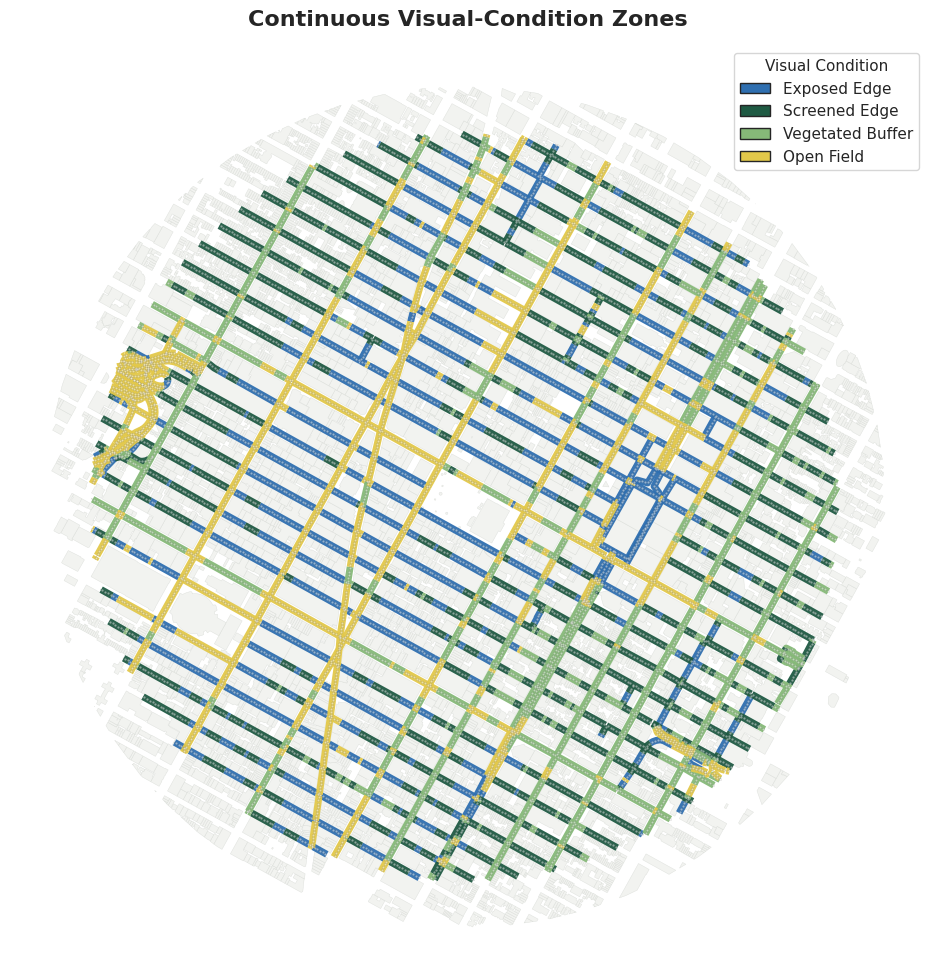

In [38]:
fig, ax = plt.subplots(figsize=(12, 12))
buildings.plot(ax=ax, facecolor=PALE_GRAY, edgecolor=LIGHT_GRAY, linewidth=0.3, alpha=0.9, zorder=1)
streets.plot(ax=ax, color=MID_GRAY, linewidth=0.65, alpha=0.75, zorder=2)

for condition in CATEGORY_ORDER:
    subset = visual_zones[visual_zones["visual_condition"].astype(str) == condition]
    subset.plot(ax=ax, color=VISUAL_COLORS[condition], linewidth=5.0, alpha=0.95, zorder=3)

sample_results.plot(ax=ax, color=WHITE, edgecolor=INK, linewidth=0.15, markersize=3, alpha=0.45, zorder=4)
legend_handles = [Patch(facecolor=VISUAL_COLORS[c], edgecolor=INK, label=c) for c in CATEGORY_ORDER]
ax.legend(handles=legend_handles, title="Visual Condition", loc="upper right")
ax.set_title("Continuous Visual-Condition Zones", fontsize=16, fontweight="bold", pad=14)
ax.set_axis_off()
plt.show()


## 16 — Identify stable zones with stronger screening potential

For the next application phase, the model needs candidate **environmental zones**, not yet final micro-refuge destinations.

A zone is highlighted here when:

- its condition is **Screened Edge** or **Vegetated Buffer**, and
- the condition persists for at least two consecutive 10 m samples.

This continuity rule is tied directly to the sampling resolution. It does not claim that the zone is comfortable, quiet, safe, or physically sittable. The next phase must overlay real pause locations.

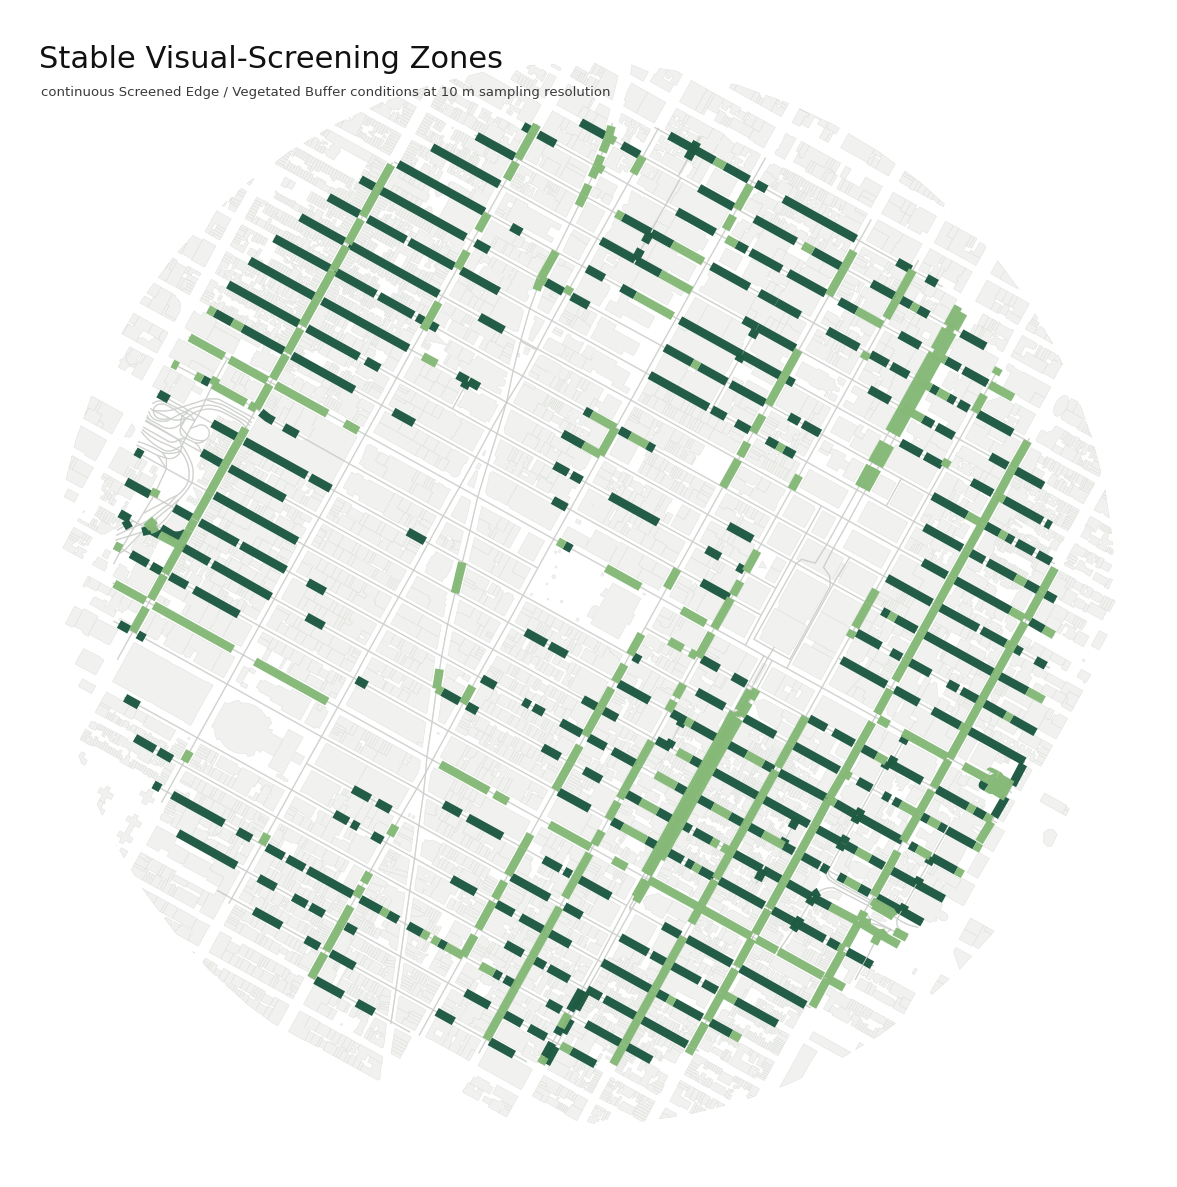

Saved: outputs/stable_visual_screening_zones.png


In [39]:
screening_zones = visual_zones[visual_zones["stable_screening_zone"]].copy()

fig, ax = plt.subplots(figsize=(12, 12), facecolor=WHITE)
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

# Neutral urban base: the data, not the basemap, carries the color.
buildings.plot(ax=ax, facecolor=PALE_GRAY, edgecolor=LIGHT_GRAY, linewidth=0.3, alpha=0.95, zorder=1)
streets.plot(ax=ax, color=MID_GRAY, linewidth=0.8, alpha=0.72, zorder=2)
visual_zones.plot(ax=ax, color=LIGHT_GRAY, linewidth=1.0, alpha=0.48, zorder=3)

for condition in ["Screened Edge", "Vegetated Buffer"]:
    subset = screening_zones[screening_zones["visual_condition"].astype(str) == condition]
    subset.plot(
        ax=ax, color=VISUAL_COLORS[condition], linewidth=6.2,
        alpha=0.98, zorder=4
    )

ax.text(
    0.025, 0.97, "Stable Visual-Screening Zones",
    transform=ax.transAxes, ha="left", va="top",
    fontsize=22, color=BLACK, fontweight="medium"
)
ax.text(
    0.027, 0.935,
    "continuous Screened Edge / Vegetated Buffer conditions at 10 m sampling resolution",
    transform=ax.transAxes, ha="left", va="top",
    fontsize=9.5, color=CHARCOAL
)
ax.set_axis_off()
plt.tight_layout()

presentation_path = OUTPUT_DIR / "stable_visual_screening_zones.png"
fig.savefig(presentation_path, dpi=320, bbox_inches="tight", facecolor=WHITE)
plt.show()
print("Saved:", presentation_path)


## 17 — Compare street orientation

Street orientation is **not** part of the classification formula. It is used afterward as an explanatory variable to ask whether the visual conditions are spatially organized by the Manhattan street structure.

PERCENTAGE OF SAMPLE POINTS WITHIN EACH ORIENTATION GROUP


visual_condition,Exposed Edge,Screened Edge,Vegetated Buffer,Open Field
orientation_group,,,,
East–West / Cross-street-like,30.8,37.8,14.4,16.9
North–South / Avenue-like,9.4,3.8,41.8,45.0


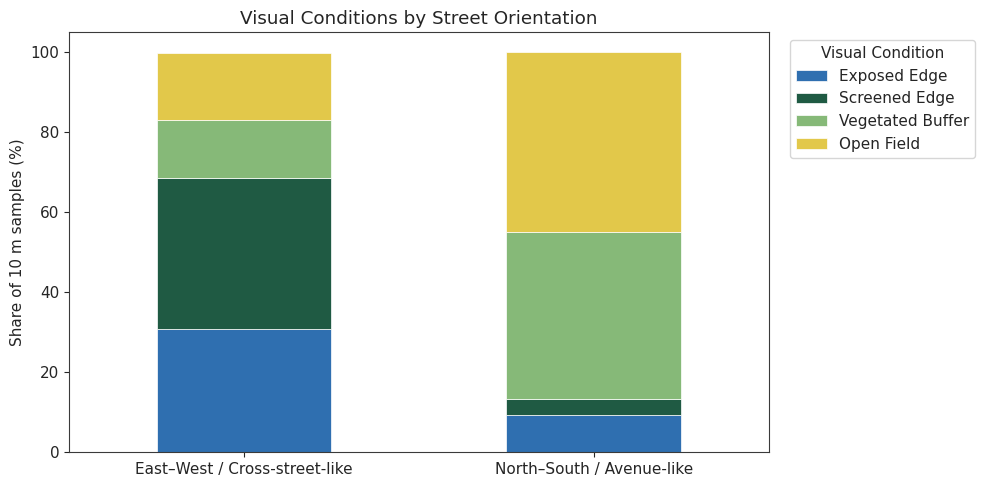

In [40]:
def segment_orientation(geom):
    coords = list(geom.coords)
    if len(coords) < 2:
        return "Unclassified"
    dx = abs(coords[-1][0] - coords[0][0])
    dy = abs(coords[-1][1] - coords[0][1])
    return "North–South / Avenue-like" if dy > dx else "East–West / Cross-street-like"

orientation_lookup = streets.set_index("segment_id").geometry.apply(segment_orientation)
sample_results["orientation_group"] = sample_results["segment_id"].map(orientation_lookup)

orientation_table = pd.crosstab(
    sample_results["orientation_group"],
    sample_results["visual_condition"],
    normalize="index"
).mul(100).round(1)

print("PERCENTAGE OF SAMPLE POINTS WITHIN EACH ORIENTATION GROUP")
display(orientation_table)

ax = orientation_table[CATEGORY_ORDER].plot(
    kind="bar", stacked=True, figsize=(10, 5),
    color=[VISUAL_COLORS[c] for c in CATEGORY_ORDER],
    edgecolor=WHITE, linewidth=0.5
)
ax.set_ylabel("Share of 10 m samples (%)")
ax.set_xlabel("")
ax.set_title("Visual Conditions by Street Orientation")
ax.legend(title="Visual Condition", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 18 — Data-supported findings

Because the analysis extent is now larger, all descriptive findings should be read from the newly recomputed sample field rather than carried over from the earlier core-area version.

The main analytical questions are:
- Which visual conditions dominate in different street orientations?
- Where do stable screening-potential zones form?
- How many real DOT pause assets fall into each visual condition?
- How much extra distance might a user trade for a more screened pause location in the later web tool?

In [41]:
class_counts = sample_results["visual_condition"].value_counts(sort=False)
class_pct = (class_counts / len(sample_results) * 100).round(1)

print("DATA-SUPPORTED FINDINGS — RECOMPUTED FOR THE 15-MINUTE AREA")
print("—" * 76)
print(f"1. {len(streets):,} street segments are represented by {len(sample_results):,} measurement points at approximately 10 m intervals.")
print(f"2. The field contains {len(visual_zones):,} continuous visual-condition zones, including {visual_zones['stable_screening_zone'].sum():,} stable screening-potential zones.")

for group in orientation_table.index:
    dominant = orientation_table.loc[group].idxmax()
    value = orientation_table.loc[group, dominant]
    print(f"3. {group}: {dominant} is the largest condition share ({value:.1f}%).")

print("4. These are proximity-based environmental conditions, not direct observations of privacy, safety, comfort, quietness, or human visibility.")

DATA-SUPPORTED FINDINGS — RECOMPUTED FOR THE 15-MINUTE AREA
————————————————————————————————————————————————————————————————————————————
1. 962 street segments are represented by 8,894 measurement points at approximately 10 m intervals.
2. The field contains 2,146 continuous visual-condition zones, including 672 stable screening-potential zones.
3. East–West / Cross-street-like: Screened Edge is the largest condition share (37.8%).
3. North–South / Avenue-like: Open Field is the largest condition share (45.0%).
4. These are proximity-based environmental conditions, not direct observations of privacy, safety, comfort, quietness, or human visibility.


## 19 — Why this matters for the Micro-Refuge application

The current output is an **environmental field**. It does not yet tell a user where to sit.

The next layer will add real pause locations such as:

- benches;
- public seating;
- plazas;
- park seating / edges;
- other publicly accessible short-stay locations.

Each pause location can then inherit the visual condition of the nearby sampling field. The future web tool can combine:

1. **user location**;
2. **available walking time**;
3. **visual-screening preference**;
4. **real pause locations**;
5. **the visual-condition field created in this notebook**.

The application question then becomes: **among the places I can actually reach and pause, which ones provide the kind of visual retreat I want?**

## 20 — Limitations

The analysis still does not include:

- actual benches or public seating in this phase;
- pedestrian travel time;
- noise, crowding, shade, temperature, or safety;
- building height, façade orientation, or window density;
- tree-canopy width, density, or seasonal foliage;
- eye height, viewing direction, or actual lines of sight;
- temporary obstacles such as vehicles, construction, or crowds.

The 10 m interval is a chosen analytical resolution, not a universal standard. Near/Far thresholds remain relative to this study area. A tree or building being close does not prove that it blocks or creates a sightline.

The model therefore represents **potential visual-buffering conditions** that can support a future micro-refuge selection tool.

## 21 — Export the high-resolution results

In [42]:
sample_export = sample_results[[
    "sample_id", "segment_id", "street_name", "sample_index", "distance_along_m",
    "tree_distance_m", "building_distance_m", "tree_class", "building_class",
    "visual_condition", "orientation_group", "zone_id", "geometry"
]].copy()
sample_export["visual_condition"] = sample_export["visual_condition"].astype(str)
sample_export = sample_export.to_crs("EPSG:4326")

zone_export = visual_zones[[
    "zone_id", "segment_id", "street_name", "visual_condition", "sample_count",
    "zone_length_m", "mean_tree_distance_m", "mean_building_distance_m",
    "stable_zone", "screening_potential", "stable_screening_zone", "geometry"
]].copy()
zone_export["visual_condition"] = zone_export["visual_condition"].astype(str)
zone_export = zone_export.to_crs("EPSG:4326")

sample_geojson = OUTPUT_DIR / "bryant_park_visual_sampling_points.geojson"
sample_csv = OUTPUT_DIR / "bryant_park_visual_sampling_points.csv"
zone_geojson = OUTPUT_DIR / "bryant_park_visual_zones.geojson"
zone_csv = OUTPUT_DIR / "bryant_park_visual_zones.csv"

sample_export.to_file(sample_geojson, driver="GeoJSON")
sample_export.drop(columns="geometry").to_csv(sample_csv, index=False)
zone_export.to_file(zone_geojson, driver="GeoJSON")
zone_export.drop(columns="geometry").to_csv(zone_csv, index=False)

print("Saved:", sample_geojson)
print("Saved:", sample_csv)
print("Saved:", zone_geojson)
print("Saved:", zone_csv)

Saved: outputs/bryant_park_visual_sampling_points.geojson
Saved: outputs/bryant_park_visual_sampling_points.csv
Saved: outputs/bryant_park_visual_zones.geojson
Saved: outputs/bryant_park_visual_zones.csv


## Current Output

After the expanded notebook runs successfully, it produces:
- an approximate 15-minute Bryant Park study field;
- 10 m street sampling points;
- nearest-tree and nearest-building-edge measurements;
- four visual-condition classes;
- continuous visual-condition zones;
- a DOT-only pool of benches and leaning bars;
- each DOT pause candidate linked to its surrounding visual condition;
- GeoJSON / CSV files prepared for the later web application.

The included `dot_pause_candidates_approx_15min.*` files are already prepared from the DOT dataset. The expanded tree / building / street outputs are generated on first notebook run because the active 15-minute source subsets are downloaded from NYC Open Data.

## 22 — Add real NYC DOT pause locations

The destination layer is now intentionally narrow and consistent: **NYC DOT Seating Locations only**.

We keep both:
- **Benches** — backed, backless, and other bench subtypes;
- **Leaning bars** — appropriate for a brief pause even when the user does not need a full seat.

POPS are removed from this version so the project does not mix facilities with different access rules and spatial meanings.

For preparation, candidates are selected within 1,200 m of Bryant Park. This is an approximate 15-minute radial pool; actual web reachability will later be calculated along the pedestrian network.

In [43]:
DOT_SEATING_FILE = DATA_DIR / "nyc_dot_seating_locations_2026-06-05.csv"

dot_seating = pd.read_csv(DOT_SEATING_FILE).dropna(subset=["Latitude", "Longitude"]).copy()
dot_gdf_all = gpd.GeoDataFrame(
    dot_seating,
    geometry=gpd.points_from_xy(dot_seating["Longitude"], dot_seating["Latitude"]),
    crs="EPSG:4326"
).to_crs(TARGET_CRS)

center_geom = center_projected.geometry.iloc[0]
dot_gdf_all["radial_distance_m"] = dot_gdf_all.geometry.distance(center_geom) * M_PER_FT
dot_gdf = dot_gdf_all[dot_gdf_all["radial_distance_m"] <= ANALYSIS_RADIUS_M].copy()

dot_gdf["candidate_id"] = "DOT_" + dot_gdf["SiteID"].astype(str)
dot_gdf["candidate_type"] = np.where(
    dot_gdf["Asset_Subtype"].fillna("").str.contains("LEANING BAR", case=False),
    "Leaning Bar",
    "Bench"
)
dot_gdf["candidate_name"] = (
    dot_gdf["Nearest_Add"].fillna("").replace("", np.nan)
    .fillna(dot_gdf["On_Street"])
    .fillna(dot_gdf["SiteID"].astype(str))
)
dot_gdf["access_note"] = "NYC DOT public seating asset"
dot_gdf["seating_type"] = dot_gdf["Asset_Subtype"]
dot_gdf["approx_minutes_radial"] = dot_gdf["radial_distance_m"] / ASSUMED_WALK_SPEED_M_PER_MIN

pause_candidates = dot_gdf[[
    "candidate_id", "candidate_type", "candidate_name", "access_note", "seating_type",
    "radial_distance_m", "approx_minutes_radial", "Latitude", "Longitude", "geometry"
]].copy()

print(f"DOT pause candidates in the 1,200 m preparation pool: {len(pause_candidates):,}")
print(pause_candidates["candidate_type"].value_counts())
print()
print("Important: the 1,200 m radius defines the preparation pool only; it is not a true walking isochrone.")

display(
    pause_candidates[[
        "candidate_type", "candidate_name", "seating_type",
        "radial_distance_m", "approx_minutes_radial"
    ]].sort_values("radial_distance_m").head(15)
)

DOT pause candidates in the 1,200 m preparation pool: 47
candidate_type
Bench          34
Leaning Bar    13
Name: count, dtype: int64

Important: the 1,200 m radius defines the preparation pool only; it is not a true walking isochrone.


,candidate_type,candidate_name,seating_type,radial_distance_m,approx_minutes_radial
1940,Bench,1060 6 Avenue,BACKLESS 2.0,108.506625,1.356333
853,Leaning Bar,6 Avenue,LEANING BAR,124.616594,1.557707
3027,Bench,12 E 42 Street,BACKLESS 2.0,239.248280,2.990603
707,Bench,1010 6 Avenue,BACKLESS 2.0,285.867549,3.573344
1997,Leaning Bar,990 6 Avenue,LEANING BAR,353.702824,4.421285
1826,Bench,22 Madison Avenue,BACKLESS 2.0,395.239302,4.940491
3267,Bench,386 5 Avenue,BACKLESS 2.0,451.172017,5.639650
357,Bench,562 5 Avenue,BACKLESS 2.0,455.149479,5.689368
950,Bench,966 6 Avenue,BACKLESS 2.0,455.398804,5.692485
762,Bench,950 6 Avenue,BACKLESS 2.0,503.025000,6.287812


## 23 — Attach the visual-condition field to each DOT pause candidate

The DOT point tells us **where a person can pause**. The nearest 10 m environmental sample tells us **what kind of visual condition surrounds that pause location**.

This keeps the roles separate:
- sample points = measurement infrastructure;
- DOT seating = destinations.

The candidate-to-sample link distance is preserved as a quality-control field.

In [44]:

pause_projected = pause_candidates.copy()
samples_for_join = sample_results[[
    "sample_id", "segment_id", "street_name", "tree_distance_m", "building_distance_m",
    "tree_class", "building_class", "visual_condition", "orientation_group", "geometry"
]].copy()
samples_for_join["visual_condition"] = samples_for_join["visual_condition"].astype(str)

candidate_join = gpd.sjoin_nearest(
    pause_projected,
    samples_for_join,
    how="left",
    distance_col="sample_link_distance_ft"
).copy()

# Resolve any equal-distance ties by retaining the first linked sample for each candidate.
candidate_join = (
    candidate_join.sort_values(["candidate_id", "sample_link_distance_ft"])
    .drop_duplicates("candidate_id", keep="first")
    .reset_index(drop=True)
)
candidate_join["sample_link_distance_m"] = candidate_join["sample_link_distance_ft"] * M_PER_FT
candidate_join["screening_potential"] = candidate_join["visual_condition"].isin(
    ["Screened Edge", "Vegetated Buffer"]
)

candidate_summary = (
    candidate_join.groupby(["candidate_type", "visual_condition"], dropna=False)
    .size().rename("count").reset_index()
)

display(candidate_summary)

print("Candidates with screening-potential conditions:", int(candidate_join["screening_potential"].sum()))
print("Median candidate-to-sample link distance: {:.1f} m".format(candidate_join["sample_link_distance_m"].median()))


,candidate_type,visual_condition,count
0,Bench,Exposed Edge,1
1,Bench,Open Field,11
2,Bench,Screened Edge,2
3,Bench,Vegetated Buffer,20
4,Leaning Bar,Open Field,9
5,Leaning Bar,Vegetated Buffer,4


Candidates with screening-potential conditions: 26
Median candidate-to-sample link distance: 10.5 m


## 24 — Map the real DOT pause candidates over the visual-condition field

This is the bridge from analysis to application. The street samples describe the environmental field; the DOT assets identify the real places where a short pause is physically supported.

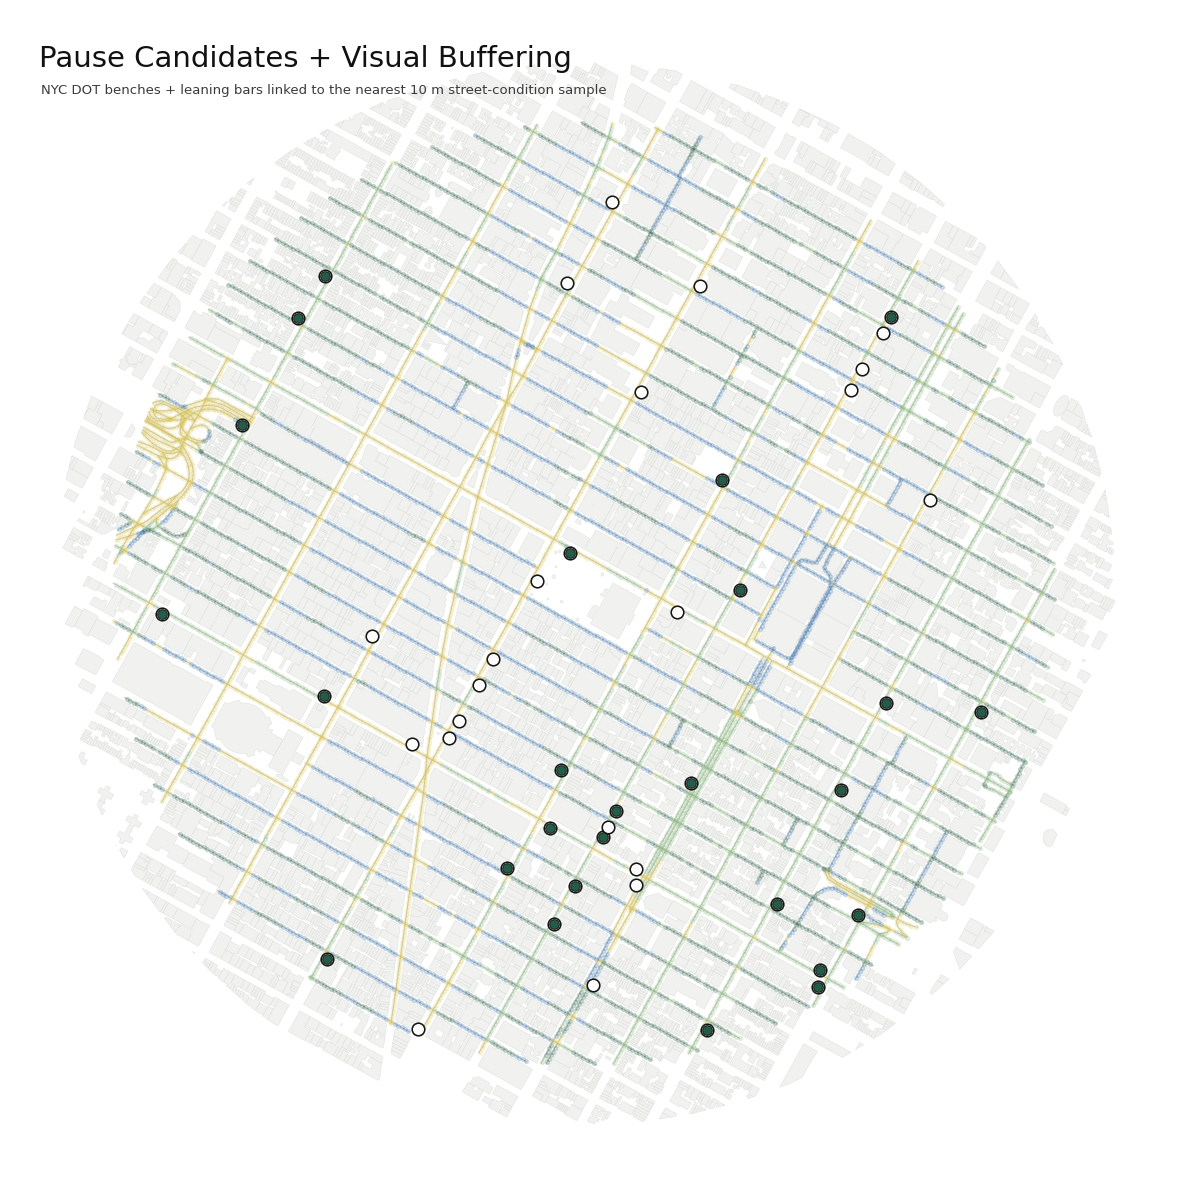

Saved: outputs/pause_candidates_visual_conditions.png


In [45]:
fig, ax = plt.subplots(figsize=(12, 12), facecolor=WHITE)
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

buildings.plot(ax=ax, facecolor=PALE_GRAY, edgecolor=LIGHT_GRAY, linewidth=0.3, alpha=0.95, zorder=1)
streets.plot(ax=ax, color=MID_GRAY, linewidth=0.75, alpha=0.70, zorder=2)

# The four visual conditions remain visible but restrained behind the real pause assets.
for condition in CATEGORY_ORDER:
    subset = sample_results[sample_results["visual_condition"].astype(str) == condition]
    subset.plot(
        ax=ax, color=VISUAL_COLORS[condition], markersize=8,
        alpha=0.20, zorder=3
    )

# All real DOT pause locations are black rings.
candidate_join.plot(
    ax=ax, facecolor=WHITE, edgecolor=BLACK, markersize=82,
    linewidth=1.15, alpha=0.98, zorder=5
)

# Candidates linked to screening conditions are filled in deep green.
screened_candidates = candidate_join[candidate_join["screening_potential"]].copy()
screened_candidates.plot(
    ax=ax, color=DEEP_GREEN, edgecolor=BLACK, markersize=48,
    linewidth=0.65, alpha=0.98, zorder=6
)

ax.text(
    0.025, 0.97, "Pause Candidates + Visual Buffering",
    transform=ax.transAxes, ha="left", va="top",
    fontsize=21, color=BLACK, fontweight="medium"
)
ax.text(
    0.027, 0.937,
    "NYC DOT benches + leaning bars linked to the nearest 10 m street-condition sample",
    transform=ax.transAxes, ha="left", va="top",
    fontsize=9.5, color=CHARCOAL
)
ax.set_axis_off()
plt.tight_layout()

pause_map_path = OUTPUT_DIR / "pause_candidates_visual_conditions.png"
fig.savefig(pause_map_path, dpi=320, bbox_inches="tight", facecolor=WHITE)
plt.show()
print("Saved:", pause_map_path)


## 25 — Export DOT Micro-Refuge candidates for the web phase

Each record combines:
- a real NYC DOT pause asset;
- its radial distance from the Bryant Park reference point;
- its linked 10 m environmental sample;
- tree and building proximity;
- its visual-condition type;
- whether that type has stronger screening potential.

The web phase will replace the radial approximation with **actual pedestrian-network travel time** from the user's selected location.

In [46]:
pause_export = candidate_join[[
    "candidate_id", "candidate_type", "candidate_name", "access_note", "seating_type",
    "radial_distance_m", "approx_minutes_radial",
    "sample_id", "segment_id", "street_name", "sample_link_distance_m",
    "tree_distance_m", "building_distance_m", "tree_class", "building_class",
    "visual_condition", "orientation_group", "screening_potential", "geometry"
]].copy()
pause_export = pause_export.to_crs("EPSG:4326")

pause_geojson = OUTPUT_DIR / "bryant_park_dot_pause_candidates_15min.geojson"
pause_csv = OUTPUT_DIR / "bryant_park_dot_pause_candidates_15min.csv"

pause_export.to_file(pause_geojson, driver="GeoJSON")
pause_export.drop(columns="geometry").to_csv(pause_csv, index=False)

print("Saved:", pause_geojson)
print("Saved:", pause_csv)
print()
print("READY FOR WEB PHASE")
print("User location + 5/10/15-minute pedestrian-network reachability -> DOT pause candidates -> visual-condition comparison")

Saved: outputs/bryant_park_dot_pause_candidates_15min.geojson
Saved: outputs/bryant_park_dot_pause_candidates_15min.csv

READY FOR WEB PHASE
User location + 5/10/15-minute pedestrian-network reachability -> DOT pause candidates -> visual-condition comparison


## 26 — Current application logic

The project now has three connected layers:

**1. Environmental field**  
Street network → 10 m samples → nearest tree / building edge → visual conditions → continuous local zones

**2. Real pause infrastructure**  
NYC DOT Seating Locations → benches + leaning bars → approximate 15-minute Bryant Park candidate pool

**3. Application layer (next web phase)**  
User location → actual pedestrian-network 5 / 10 / 15-minute reachability → reachable DOT assets → compare visual conditions → choose a more screened short-pause option

The key application argument is: **the nearest place to pause is not necessarily the place that offers the visual condition the user wants.**